# Preparing the AfriMed-QA Data

The assistant built in this project answers medical questions by retrieving human-written answers from the AfriMed-QA v2.5 dataset, so the quality of those answers, and the way they are divided for training and testing, affects every result that follows. This notebook therefore begins by exploring the raw file to understand what it contains. It then uses what we learn to clean the records, remove the ones that are unsuitable for question answering, and create the training, validation and test sets used by the later notebooks.

The cleaned files are saved in `data/processed/`, and the same decisions are summarised in the Preparing the Data section of the README. To run the notebook on Google Colab, clone the repository, move into its folder and install the packages in `requirements.txt` before running the cells.

In [1]:
# Work from the repository root so that `src` can be imported and the data paths resolve.
import os, sys, warnings
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
warnings.filterwarnings("ignore")

import pandas as pd
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

import json, re
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import GroupShuffleSplit

from src.config import RAW_CSV, PROCESSED_DIR, RESULTS_DIR, FIGURES_DIR, SEED, VAL_FRACTION, BASE_MODEL
from src.text_cleaning import clean_question, clean_answer, normalize_whitespace, strip_leaked_answer
PROCESSED_DIR.mkdir(parents=True, exist_ok=True); FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Understanding the Dataset

We start by loading the complete file and checking which kinds of questions it contains. AfriMed-QA mixes several question types, and only some of them are suitable for an assistant that returns written answers.

In [2]:
df = pd.read_csv(RAW_CSV)
print("records:", len(df), "| columns:", df.shape[1])
print(list(df.columns))
df.question_type.value_counts()

records: 15275 | columns: 30
['sample_id', 'split', 'gender', 'discipline', 'clinical_experience', 'country', 'question_type', 'prompt', 'question', 'question_clean', 'answer_options', 'correct_answer', 'answer_rationale', 'specialty', 'region_specific', 'mentions_Africa', 'mentions_age', 'mentions_gender', 'tier', 'neg_percent', 'quality', 'rated_african', 'rated_correct', 'rated_omission', 'rated_hallucination', 'rated_reasonable', 'rated_harmful', 'rated_bias', 'version', 'requires_african_expertise']


question_type
consumer_queries    10000
mcq                  4039
saq                  1236
Name: count, dtype: int64

The file contains 15,275 records and 30 columns. Most records are consumer queries (10,000) or multiple-choice questions (4,039), and only 1,236 are Short Answer Questions (SAQ). The consumer queries have no answers, and the multiple-choice questions were written to be answered by choosing an option, so neither type provides the kind of written explanation that the assistant should return. We therefore keep the SAQ records, and the next step is to find where their questions and answers are stored.

## Finding the Question and Answer Columns

The column names do not make it obvious where an SAQ answer is stored, because the file also contains several answer columns that were designed for multiple-choice questions. Counting the non-empty values of each candidate column for the SAQ records shows which ones are actually used.

In [3]:
saq = df[df.question_type == "saq"].reset_index(drop=True)
print("SAQ records:", len(saq))
saq[["question", "question_clean", "answer_rationale", "correct_answer", "answer_options", "prompt"]].notna().sum().rename("non-empty values")

SAQ records: 1236


question            1236
question_clean      1236
answer_rationale    1236
correct_answer         0
answer_options         0
prompt                 0
Name: non-empty values, dtype: int64

Every SAQ record has a question and a value in `answer_rationale`, while `correct_answer` and `answer_options` are always empty. For this question type, `answer_rationale` therefore holds the human-written answer, and we use it as the answer column. Two question columns are available, `question` and `question_clean`, and we compare them below before choosing one.

## Checking Missing Values and Duplicates

Before looking at the content of the records, we check for two basic problems. A record without a question or an answer cannot be used by a retrieval system, and duplicate records can make the evaluation misleading, since a question that appears in both the training and the test data would be answered correctly for the wrong reason. The texts are compared after lowercasing them and collapsing extra spaces, so that small formatting differences do not hide duplicates.

In [4]:
norm = lambda t: normalize_whitespace(t).lower()   # Lowercase and collapse spaces so formatting does not hide duplicates.
q, a = saq.question.map(norm), saq.answer_rationale.map(norm)
blank = lambda s: s.isna() | (s.fillna("").str.strip() == "")
pd.Series({
    "missing questions": blank(saq.question).sum(),
    "missing answers": blank(saq.answer_rationale).sum(),
    "exact duplicate questions": saq.question.duplicated().sum(),
    "duplicate questions ignoring case/spaces": q.duplicated().sum(),
    "duplicate question-answer pairs": pd.concat([q, a], axis=1).duplicated().sum(),
    "same question with different answers": pd.DataFrame({"q": q, "a": a}).groupby("q").a.nunique().gt(1).sum(),
    "answers shared by several questions": a.duplicated().sum(),
}, name="count")

missing questions                           0
missing answers                             0
exact duplicate questions                   0
duplicate questions ignoring case/spaces    0
duplicate question-answer pairs             0
same question with different answers        0
answers shared by several questions         8
Name: count, dtype: int64

No question or answer is missing, and there are no duplicate questions, even after ignoring case and spacing. The only warning sign is that 8 answers are shared by more than one question. Exact comparisons like these cannot detect records that are almost the same, such as one question written in two slightly different ways, so we return to this problem with a similarity check later in the notebook.

## Choosing Between `question` and `question_clean`

The dataset provides a column called `question_clean`, which suggests that it is the better version to use. Before relying on it, we compare it with the original `question` column and list the words that it changes.

In [5]:
changed = saq[saq.question != saq.question_clean]
content = changed[changed.question.map(normalize_whitespace) != changed.question_clean.map(normalize_whitespace)]
print("rows that differ:", len(changed), "| differ beyond whitespace:", len(content))
tokens = set()
for raw, cln in zip(content.question, content.question_clean):
    r, c = normalize_whitespace(raw).split(), normalize_whitespace(cln).split()
    tokens.update((x, " ".join(w for w in c if w not in r)) for x in set(r) - set(c))
pd.DataFrame(sorted(tokens)[:20], columns=["in `question`", "becomes in `question_clean`"])

rows that differ: 68 | differ beyond whitespace: 27


,in `question`,becomes in `question_clean`
0,(2marks),(2 marks)
1,(5m),(5 m)
2,(G6PD),(G 6 PD)
3,(mHealth),(m Health)
4,-,serum-ascites
5,-3,<-3
6,"100kg,","100 kg, m L m L m L"
7,12kg,12 kg
8,27yr,"27 yr 6 g,"
9,2X2,2 X 2


Of the 68 questions that differ, only 27 differ in more than their spacing, and the changes in these questions are not improvements. `question_clean` inserts spaces inside medical terms and units, so G6PD becomes "G 6 PD", HER2 becomes "HER 2", B12 becomes "B 12" and mL becomes "m L". Splitting such terms would make them harder to recognise for both TF-IDF and the Transformer model. We therefore use the original `question` column and apply our own light cleaning, which is described in the cleaning section below.

## Looking at the Contributors and the Official Split

The SAQ records were written by contributors in different countries and with different levels of expertise. We look at their country, their medical specialty and the dataset's own train and test labels, because these characteristics determine how representative our evaluation can be.

In [6]:
display(saq.country.value_counts().rename("records by country").to_frame().T)
display(saq.specialty.fillna("(not given)").value_counts().rename("records by specialty").to_frame().T)
pd.crosstab(saq.split, [saq.tier, saq.country])

country,NG,KE,MW
records by country,923,195,118


specialty,(not given),General_Surgery,Pediatrics,Internal_Medicine,Obstetrics_and_Gynecology,Endocrinology,Other,Orthopedic_Surgery,Hematology,Oncology,Family_Medicine,Neurology,Pathology,Allergy_and_Immunology,Pulmonary_Medicine
records by specialty,875,180,57,53,38,8,6,5,5,2,2,2,1,1,1


tier    crowdsourced expert         
country           NG     KE   MW  NG
split                               
test               0    195  118  46
train            877      0    0   0

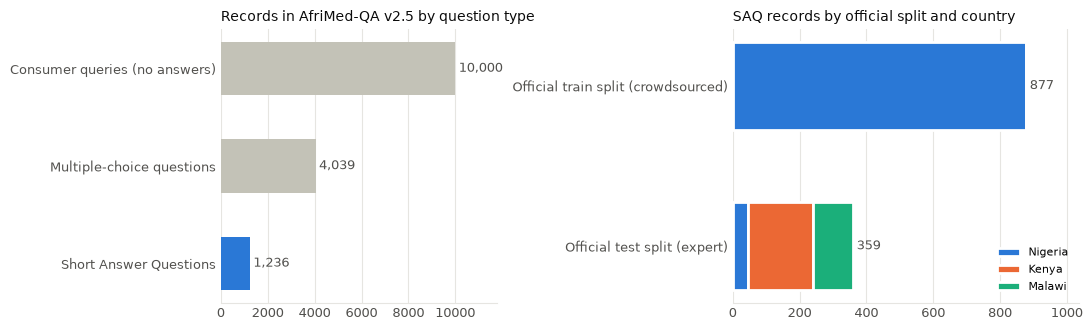

In [7]:
import matplotlib.pyplot as plt
BLUE, ORANGE, AQUA, YELLOW, LIGHT = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#c3c2b7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"

def tidy(ax, grid_axis="y"):
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right", "left" if grid_axis == "x" else "top"]:
        ax.spines[side].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK2, labelsize=9, length=0)

# Question types in the whole file, and the SAQ records by official split and country.
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [1, 1.25]})
types = df.question_type.value_counts()
names = {"consumer_queries": "Consumer queries (no answers)", "mcq": "Multiple-choice questions", "saq": "Short Answer Questions"}
left.barh([names[t] for t in types.index], types.values, height=0.55,
          color=[BLUE if t == "saq" else LIGHT for t in types.index])
for y, v in enumerate(types.values):
    left.text(v + 150, y, f"{v:,}", va="center", fontsize=9, color=INK2)
left.invert_yaxis(); left.set_xlim(0, types.max() * 1.18)
left.set_title("Records in AfriMed-QA v2.5 by question type", loc="left", fontsize=10, color=INK)

counts = saq.groupby(["split", "country"]).size().unstack(fill_value=0).loc[["train", "test"], ["NG", "KE", "MW"]]
bars = ["Official train split (crowdsourced)", "Official test split (expert)"]
start = np.zeros(2)
for country, label, color in [("NG", "Nigeria", BLUE), ("KE", "Kenya", ORANGE), ("MW", "Malawi", AQUA)]:
    right.barh(bars, counts[country].values, left=start, height=0.55, color=color, edgecolor="white", linewidth=2, label=label)
    start += counts[country].values
for y, total in enumerate(start):
    right.text(total + 12, y, f"{int(total):,}", va="center", fontsize=9, color=INK2)
right.invert_yaxis(); right.set_xlim(0, start.max() * 1.18)
right.legend(frameon=False, fontsize=8, loc="lower right")
right.set_title("SAQ records by official split and country", loc="left", fontsize=10, color=INK)
for ax in (left, right):
    tidy(ax, "x")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "dataset_overview.png", dpi=200); plt.show()

Nigeria contributed most records (923), followed by Kenya (195) and Malawi (118), and a specialty is recorded for only 361 records, about half of them in General Surgery. The most important finding, however, is that the official split follows the source of the records exactly. All 877 training records are crowdsourced questions from Nigeria, while all 359 test records were written by experts in Kenya, Malawi and Nigeria. The two groups also differ in style: the crowdsourced questions are general and usually have fluent one-sentence answers, whereas the expert questions resemble exam prompts and often have short list answers.

We decided to keep the official split and leave the test set untouched, because the project guidelines ask us to preserve the dataset's split when possible. The validation set is therefore taken only from the official training records. This decision has a clear consequence for the rest of the project. The test results will measure how well a model trained on crowdsourced questions transfers to expert questions, so they are expected to be lower than the validation results.

## Checking Lengths, Quality Ratings and Formatting

Next we look at how long the questions and answers are, whether the dataset includes quality ratings, and what formatting noise appears in the text. Each of these points matters for a later step: lengths affect the model's input limit, quality ratings can identify unreliable answers, and formatting noise decides how much cleaning is needed.

In [8]:
words = lambda s: s.str.split().str.len()
display(pd.DataFrame({"question words": words(saq.question).describe(),
                      "answer words (crowdsourced)": words(saq.answer_rationale[saq.tier == "crowdsourced"]).describe(),
                      "answer words (expert)": words(saq.answer_rationale[saq.tier == "expert"]).describe()}).round(1).T)
rated = saq[saq.quality.notna()]
print("records with human quality ratings:", len(rated))
display(rated.groupby(rated.quality.astype(str)).agg(records=("quality", "size"), mean_rated_correct=("rated_correct", "mean")).round(2))
pd.Series({
    "questions with [Speaker N]: tag": saq.question.str.contains(r"\[speaker", case=False).sum(),
    "questions with exam marks e.g. (2marks)": saq.question.str.contains(r"\(\s*\d+\s*(?:marks?|mks?|m)\s*\)", case=False).sum(),
    "questions with line breaks": saq.question.str.contains("\n").sum(),
    "answers with line breaks": saq.answer_rationale.str.contains("\n").sum(),
    "answers starting with 'Answer:'": saq.answer_rationale.str.match(r"(?i)^\s*answer\s*:").sum(),
    "answers under 5 words": (words(saq.answer_rationale) < 5).sum(),
    "answers over 300 words": (words(saq.answer_rationale) > 300).sum(),
}, name="count")

,count,mean,std,min,25%,50%,75%,max
question words,1236.0,14.7,10.6,2.0,10.0,12.0,17.0,114.0
answer words (crowdsourced),877.0,36.3,31.8,1.0,23.0,29.0,41.0,519.0
answer words (expert),359.0,58.9,87.4,1.0,11.0,28.0,66.0,900.0


records with human quality ratings: 50


,records,mean_rated_correct
quality,,
False,6,0.33
True,44,4.86


questions with [Speaker N]: tag              1
questions with exam marks e.g. (2marks)      4
questions with line breaks                 229
answers with line breaks                   435
answers starting with 'Answer:'             30
answers under 5 words                       37
answers over 300 words                       5
Name: count, dtype: int64

Questions are short, with a median of 12 words, but answers vary much more. Crowdsourced answers are fairly regular, with a median of 29 words, while expert answers range from a single word to 900 words, which is a first sign that the test set will be harder to match. Only 50 records carry human quality ratings, and the 6 records marked `quality = False` received a mean correctness rating of 0.33 out of 5, compared with 4.86 for the others. Since the dataset's own reviewers judged these answers to be wrong, we remove them during cleaning. The formatting checks also reveal a small amount of noise, such as 30 answers that begin with "Answer:" and a few questions that contain exam marks or a transcript tag, which the cleaning step handles.

## Checking Topic Coverage

The assistant can only return answers that exist in the dataset, so it is useful to know how well common health topics are covered. We count the questions that mention a few important topics with simple keyword searches, which gives a rough rather than exact picture.

In [9]:
topics = {"malaria": r"malaria", "HIV": r"\bhiv\b", "tuberculosis": r"tuberculosis|\btb\b", "sickle cell": r"sickle",
          "diabetes": r"diabet", "hypertension": r"hypertensi", "cancer": r"cancer|carcinoma|\bca\b",
          "pregnancy/maternal": r"pregnan|maternal|obstet|antenatal", "children": r"child|paediatric|pediatric|neonat|infant",
          "traditional/herbal remedies": r"traditional|herbal|indigenous|remed|healer"}
pd.Series({k: saq.question.str.contains(p, case=False, regex=True).sum() for k, p in topics.items()}, name="questions")

malaria                         32
HIV                             35
tuberculosis                    24
sickle cell                     18
diabetes                        22
hypertension                    16
cancer                          91
pregnancy/maternal              48
children                       108
traditional/herbal remedies    119
Name: questions, dtype: int64

Even common conditions appear in only a few dozen questions: malaria in 32, HIV in 35 and hypertension in 16, while many other diseases do not appear at all. This limited coverage is the main limitation of the project, and it is the reason the assistant needs a way to refuse questions about topics the dataset does not cover. The counts also show 119 questions about traditional or herbal remedies. Their answers describe practices reported by contributors rather than clinical guidance, so the web app adds a caution when it returns one of them.

## Finding Near-Duplicates and Conflicting Answers

The exact checks found no duplicate questions, but records can still be nearly identical, for example when the same exam question was submitted twice with small changes in wording. Near-identical records in different splits would inflate the evaluation, and similar questions with different answers would give the assistant contradictory knowledge. To find such cases, we compare every pair of SAQ records with TF-IDF cosine similarity and flag a pair when its questions have a similarity of at least 0.80 or its answers have a similarity of at least 0.90. Every flagged pair was then read manually.

In [10]:
QUESTION_SIM, ANSWER_SIM = 0.80, 0.90
sim_q = cosine_similarity(TfidfVectorizer().fit_transform(q)); np.fill_diagonal(sim_q, 0)
sim_a = cosine_similarity(TfidfVectorizer().fit_transform(a)); np.fill_diagonal(sim_a, 0)
i, j = np.where(np.triu((sim_q >= QUESTION_SIM) | (sim_a >= ANSWER_SIM)))
pairs = pd.DataFrame({"id_1": saq.sample_id[i].values, "id_2": saq.sample_id[j].values,
                      "split_1": saq.split[i].values, "split_2": saq.split[j].values,
                      "question_sim": sim_q[i, j].round(2), "answer_sim": sim_a[i, j].round(2),
                      "question_1": saq.question[i].map(normalize_whitespace).values,
                      "question_2": saq.question[j].map(normalize_whitespace).values,
                      "answer_1": saq.answer_rationale[i].map(normalize_whitespace).str[:200].values,
                      "answer_2": saq.answer_rationale[j].map(normalize_whitespace).str[:200].values})
pairs.to_csv(RESULTS_DIR / "near_duplicate_candidates.csv", index=False)
print("candidate pairs:", len(pairs), "| crossing the official train/test split:", (pairs.split_1 != pairs.split_2).sum())
# Show the clearest conflict, the treatment of uncomplicated malaria.
malaria = saq[saq.question.str.contains("treatment for uncomplicated malaria", case=False)]
malaria[["sample_id", "question", "answer_rationale"]].assign(answer_rationale=malaria.answer_rationale.str[:110])

candidate pairs: 136 | crossing the official train/test split: 0


,sample_id,question,answer_rationale
190,c98a810f88f0784b48cbc6e12917020f5a91dbec71633cf9e6c5f03b161a2922,What is the first-line treatment for uncomplicated malaria in Nigeria?,"Pyrethroids, such as Deltamethrin or Alpha-cypermethrin. Pyrethroids are recommended for indoor residual spray"
369,f589c587ae24b79fb6a0cbe2f76262edf677443363a0254457beee43ddd68cf0,What is the recommended treatment for uncomplicated malaria in Africa?,Subranoid
565,75afe24b7cab4db582f921f25ad3287ffa911a01ee6d3bba413ca3d3531464a2,What is the recommended first-line treatment for uncomplicated malaria in Africa?,Artemisinin-based combination therapies (ACTs) are the recommended first-line treatment for uncomplicated mala
634,f92c46480b8d57797f4c9d2bfd395742b735c7fd0bc4dad5395f01ab648062a3,Which of the following is the first-line treatment for uncomplicated malaria in pregnant women in Africa?,The first-line treatment for uncomplicated malaria in pregnant women in Africa is Artemether-lumefantrine (AL)


The check flagged 136 pairs, and none of them crosses the official train and test split, so the test set contains no near-copies of training records. Reading the pairs showed that most of them are not problems. Many are template questions about different diseases or populations, such as "challenges in managing hypertension" and "challenges in managing diabetes", and others are sub-questions about the same clinical case. These were kept because they ask different things.

A few pairs did require action, and the table above shows the clearest case. The first-line treatment of uncomplicated malaria is asked three times with different answers, and two of those answers are wrong: "Subranoid" is not a recognised medicine, and pyrethroids are insecticides used for mosquito control rather than a treatment. We removed these two records and kept the answer recommending artemisinin-based combination therapy (ACT), which agrees with the WHO malaria guidelines. The fourth row asks about pregnant women, which is a different question, and its answer is consistent with the others, so it was kept. We also found a question about urinary tract infections whose answer, copied from another record, is about allergies, and 9 near-duplicates in which the same question and almost the same answer appear twice. The later copy of each near-duplicate is removed. Finally, the two answers to "the most common cause of anaemia in children under five" point to malaria and to iron deficiency. Because they differ in emphasis rather than contradict each other, both were kept.

## Cleaning the Text

With the main data problems identified, we can now clean the records. The cleaning is deliberately light, and the functions in `src/text_cleaning.py` are shared with the web app so that user questions are processed in the same way as the dataset questions. The cleaning removes answer text that was accidentally pasted into a question, transcript tags such as "[Speaker 2]:", exam marks such as "(2marks)", "Answer:" prefixes and stray punctuation at the start of an answer. It keeps the line breaks inside answers, because many expert answers are lists. We do not lowercase the text, remove stop words or apply stemming, since the Transformer model needs complete, natural sentences to build good representations.

In [11]:
data = saq.rename(columns={"sample_id": "id", "split": "official_split",
                           "question": "question_raw", "answer_rationale": "answer_raw"})[
    ["id", "official_split", "tier", "country", "specialty", "quality", "question_raw", "answer_raw"]].copy()
fixed = [strip_leaked_answer(qq, aa) for qq, aa in zip(data.question_raw, data.answer_raw)]
leaked = data[[f != r for f, r in zip(fixed, data.question_raw)]]
data["question"] = [clean_question(t) for t in fixed]
data["answer"] = data.answer_raw.map(clean_answer)
print("answers leaked into questions (removed):", len(leaked))
print("questions changed beyond whitespace:", (data.question != data.question_raw.map(normalize_whitespace)).sum(),
      "| answers changed beyond whitespace:",
      (data.answer.map(normalize_whitespace) != data.answer_raw.map(normalize_whitespace)).sum())
pd.DataFrame({"before": leaked.question_raw.map(normalize_whitespace).str[-80:],
              "after": data.loc[leaked.index, "question"].str[-60:]})

answers leaked into questions (removed): 4


questions changed beyond whitespace: 9 | answers changed beyond whitespace: 32


,before,after
75,What traditional African remedy is used to relieve symptoms of eczema? A,tional African remedy is used to relieve symptoms of eczema?
432,"atic heart disease, resulting from inadequately treated streptococcal infections",What is the most common cause of heart failure in Africa?
829,What is the primary mode of transmission of HIV in Africa? A,What is the primary mode of transmission of HIV in Africa?
962,ich of the MEN syndromes is associated with medullar carcinoma of thyroid. MEN 2,syndromes is associated with medullar carcinoma of thyroid.


Four questions contained part of their own answer, as the before and after columns show. Two ended with a leftover multiple-choice letter, one had its full answer written after the question mark, and one gave the answer ("MEN 2") on its last line. Leaving these in place would make the questions easy to match for the wrong reason. Apart from spacing, the cleaning changed 9 questions and 32 answers, and each change was checked by reading the texts before and after cleaning.

## Removing Unsuitable Records

After cleaning, we decide which records to remove. Some rules are automatic: a record is removed if its question field contains the answer instead of a question, if the dataset's reviewers rated it as low quality, if it is about a non-medical topic, or if it is an exact duplicate after cleaning. The remaining removals are the manual decisions described above, which are listed by record ID so that each one can be traced back to its reason.

In [12]:
# Records removed after reading the flagged pairs in results/near_duplicate_candidates.csv.
MANUAL_REMOVALS = {
    "f589c587ae24b79fb6a0cbe2f76262edf677443363a0254457beee43ddd68cf0":
        "conflicting answer: 'Subranoid' is not a recognised medicine; record 75afe24b answers the same question with ACTs",
    "c98a810f88f0784b48cbc6e12917020f5a91dbec71633cf9e6c5f03b161a2922":
        "conflicting answer: describes insecticides for mosquito control (pyrethroids), not a malaria treatment",
    "2d30b1ba16c58c2fd63d70aa3f44a795b73ed89acf68f7ffda910d9a4f93b9ee":
        "answer does not match question: asks about urinary tract infections, answer is about allergies/hay fever "
        "(identical to record 735e51b4)",
}
NEAR_DUPLICATES = [  # Each pair is (removed record, kept record).
    ("ce4464d4ba9c9b6cb78fb0a03b2d9566f352835429bbd07dd35f3e8aa3a97e94", "57b32ba11a419108bcbb9507d660a555a7232ae5bfeb50eb3afb369c6318c44f"),
    ("648cb7e69b63d1be2500b60ae6fcf4ceb6467606eb7d93a5006c567d99e2d116", "96d5acbbd1daf33e3646d12ab90a8371b4fd9d7579d4233ce8be71be2ca0a5ef"),
    ("58c5c213216fecbcb7baf2d6b98fd213329f52c470f26579f231508a57988b7a", "8023dbdc750ac068bf27adcf7b62b409611b43d81fc914c83cf87332b4795d94"),
    ("307d2f96a445b5033cf13d3c95dc4a53912c6b8c38322b46f2e384b57b84480a", "547f5ec8e4b7bebed1ec557f080faca2509f5d6746045089d9b9ba21b3fb2742"),
    ("58e4ca6b9bd3b0cfe087ba9302a7c840b4e6b85ce2b1a5d6f167fddce2a89e0e", "f7d4a78a8e7667d3bde0021cb9c75271fb9eea598b6b114e9eea5eff946e3958"),
    ("e857fcebbce8f37bc6d4a1c1262f0eb2dc3ff0376e30d97b1b008cb1b5006af6", "cd88f81af5e136d8e0a0623bceed7f5102178ba724ed0ac29b34ca0fba0968fc"),
    ("fea7baee6ca2134055f8c017e99c0b6e2d4c8fc239c856d4bf97ba95c3c53665", "cec0808f1c96301308d4a551efd8a3ef85758dc3fd90287d7a2ebd7028c74bd8"),
    ("1d1ced2d66426c5d47090b6bc9c1225fededd7cace6e7eb4110a398dd4edd35f", "ed78c366243c4f40550459ae640f8f067a28bfef3cd42bfed4a8f9643f0c373b"),
    ("a81bbe276a48cfd92ccc4d232c2d00158d3043fe523929e456aa762a4db03c3e", "9c0fc03fad4e3f2eb056342caf3faa62b2da330137a69cd9c13e9d2db3516685"),
]
for removed_id, kept_id in NEAR_DUPLICATES:
    MANUAL_REMOVALS[removed_id] = f"near-duplicate: same question meaning and near-identical answer as record {kept_id[:8]}"
assert set(MANUAL_REMOVALS) <= set(data.id), "unknown id"

# Topics found to be non-medical by the screening in the next cell.
NON_HEALTH_TOPICS = r"genealog|child labou?r"

def removal_reason(row):
    """Return the reason for removing a record according to the first matching rule, or None to keep it."""
    answer = normalize_whitespace(row.answer).lower()
    if len(answer.split()) >= 5 and answer in row.question.lower():
        return "malformed question: the question field contains the answer text instead of a question"
    if str(row.quality) == "False":
        return "low quality rating: marked quality = False by AfriMed-QA human reviewers"
    if re.search(NON_HEALTH_TOPICS, row.question, flags=re.IGNORECASE):
        return "not health-related: genealogy or child labour, outside the medical domain"
    return MANUAL_REMOVALS.get(row.id)

data["reason"] = data.apply(removal_reason, axis=1)
key = data.question.str.lower() + " || " + data.answer.map(normalize_whitespace).str.lower()
still_kept = key[data.reason.isna()]
data.loc[still_kept[still_kept.duplicated()].index, "reason"] = \
    "exact duplicate: same question and answer as an earlier record after cleaning"

removed = data[data.reason.notna()]
kept = data[data.reason.isna()].reset_index(drop=True)
print("removed:", len(removed), "| kept:", len(kept))
removed.reason.str.split(":").str[0].value_counts().rename("removed records")

removed: 30 | kept: 1206


reason
near-duplicate                    9
not health-related                8
low quality rating                6
malformed question                3
conflicting answer                2
answer does not match question    1
exact duplicate                   1
Name: removed records, dtype: int64

In total, 30 records were removed and 1,206 were kept. Near-duplicates (9) and non-medical records (8) account for more than half of the removals, followed by the 6 records rated as low quality and the 3 malformed questions whose question field contained the answer.

The non-medical rule needs some explanation, since AfriMed-QA is a medical dataset. The next cell shows how the two non-medical topics were found: we listed the records that contain none of a broad set of health-related words and then read them.

In [13]:
# List the records whose question and answer contain none of these health-related words.
health = (r"health|medic|disease|disorder|syndrome|infect|patient|clinic|hospital|treat|therap|diagnos|symptom|cancer|"
          r"carcinoma|tumou?r|malignan|virus|viral|bacteri|parasit|malaria|hiv|aids\b|tubercul|pregnan|maternal|neonat|"
          r"birth|infant|mortality|drug|vaccin|immun|surg|nutri|pain|blood|cardi|heart|renal|kidney|liver|lung|brain|"
          r"mental|psych|anemi|anaemi|diabet|hypertens|fever|injur|wound|fracture|nurs|doctor|physician|remed|herb|"
          r"healer|hygien|sanit|epidem|outbreak|contracep|sexual|reproduct|menstru|disab|obes|smok|alcohol|illness|sick|"
          r"death|dying|stigma|cure|heal|well-being|wellbeing|cognitive|development|poison|venom|burn|drown")
screen = data[~(data.question + " " + data.answer).str.contains(health, case=False, regex=True)]
print(f"{len(screen)} records contain no health word; after reading them, the clearly non-medical ones are:")
screen[screen.question.str.contains(NON_HEALTH_TOPICS, case=False)][["question"]]

87 records contain no health word; after reading them, the clearly non-medical ones are:


,question
53,How has colonialism affected African genealogical records?
244,How do African societies view adoption in terms of genealogy?
293,What is the significance of genealogy in African cultures?
458,How do African communities traditionally record and preserve genealogical information?
622,What role does genealogy play in traditional African religions?
757,What is the prevalence of child labor in specific African countries?
850,How do African diaspora communities maintain their genealogical ties to Africa?


The screen returned 87 records. Most of them are still medical, for example histopathology or anatomy questions that simply use more specialised vocabulary than our word list. Reading them showed that the clearly non-medical records are about genealogy and child labour, so the removal rule targets these two topics. It removes 8 records in total: the 7 shown above and one more child-labour record that the screen did not list because its answer contains the word "development".

## Creating the Training, Validation and Test Sets

The cleaned records can now be divided into the three sets. The test set is the official test split, which is never used for training or for choosing settings. The validation set is 15% of the official training split, and it is what we use to compare models and to choose thresholds, so that the test set remains independent.

A simple random split of the training records would not be enough, because near-identical records could end up on both sides. A near-copy of a training question in the validation set would then be answered correctly for the wrong reason, which is a form of data leakage. To prevent this, records whose questions or answers are near-identical, using the same thresholds of 0.80 and 0.90 as before, are placed in the same group, and `GroupShuffleSplit` keeps every group together in a single split.

In [14]:
def similarity_groups(frame):
    sq = cosine_similarity(TfidfVectorizer().fit_transform(frame.question.str.lower()))
    sa = cosine_similarity(TfidfVectorizer().fit_transform(frame.answer.map(normalize_whitespace).str.lower()))
    _, labels = connected_components(csr_matrix((sq >= QUESTION_SIM) | (sa >= ANSWER_SIM)), directed=False)
    return labels

kept["group_id"] = similarity_groups(kept)
kept["split"] = "test"
pool = kept.index[kept.official_split == "train"]
train_pos, val_pos = next(GroupShuffleSplit(n_splits=1, test_size=VAL_FRACTION, random_state=SEED)
                          .split(pool, groups=kept.loc[pool, "group_id"]))
kept.loc[pool[train_pos], "split"] = "train"
kept.loc[pool[val_pos], "split"] = "val"

# Check that the split is valid before saving it.
assert (kept.question.str.len() > 0).all() and (kept.answer.str.len() > 0).all()
assert not kept.question.str.lower().duplicated().any()
assert kept.groupby("group_id").split.nunique().max() == 1, "a similarity group spans two splits"
assert (kept.loc[kept.split == "test", "official_split"] == "test").all()
sizes = kept.group_id.value_counts()
print("groups:", len(sizes), "| groups with >= 2 records:", (sizes > 1).sum(), "| largest:", sizes.max())
pd.crosstab(kept.split, [kept.tier, kept.country], margins=True)

groups: 1107 | groups with >= 2 records: 64 | largest: 10


tier    crowdsourced expert            All
country           NG     KE   MW  NG      
split                                     
test               0    190  118  46   354
train            711      0    0   0   711
val              141      0    0   0   141
All              852    190  118  46  1206

The split produced 711 training records, 141 validation records and 354 test records. The grouping mattered for 64 groups that contain two or more records, the largest of which has 10 members, and the checks confirm that no group crosses two splits and that the test set contains only official test records. The table also shows the source difference once more: every training and validation record is a crowdsourced question from Nigeria, while the test set is written entirely by experts. With these checks passed, the next cell saves the files used by the later notebooks.

In [15]:
OUTPUT_COLUMNS = ["id", "split", "official_split", "tier", "country", "specialty", "group_id", "question", "answer"]
kept[OUTPUT_COLUMNS].to_csv(PROCESSED_DIR / "saq_clean.csv", index=False)
for name in ["train", "val", "test"]:
    kept.loc[kept.split == name, OUTPUT_COLUMNS].to_csv(PROCESSED_DIR / f"{name}.csv", index=False)
removed[["id", "official_split", "reason", "question_raw", "answer_raw"]].to_csv(PROCESSED_DIR / "removed_records.csv", index=False)

summary = {"saq_records": len(saq), "removed": len(removed),
           "removed_by_reason": removed.reason.str.split(":").str[0].value_counts().to_dict(),
           "kept": len(kept), "split_sizes": kept.split.value_counts().to_dict(),
           "leaked_answers_fixed": len(leaked)}
json.dump(summary, open(RESULTS_DIR / "preparation_summary.json", "w"), indent=2)
summary

{'saq_records': 1236,
 'removed': 30,
 'removed_by_reason': {'near-duplicate': 9,
  'not health-related': 8,
  'low quality rating': 6,
  'malformed question': 3,
  'conflicting answer': 2,
  'answer does not match question': 1,
  'exact duplicate': 1},
 'kept': 1206,
 'split_sizes': {'train': 711, 'test': 354, 'val': 141},
 'leaked_answers_fixed': 4}

## Checking Text Length in Model Tokens

Before moving on to modelling, we check whether the texts fit the model we plan to use. The Transformer model reads WordPiece tokens rather than words, and its model card states that input longer than 512 tokens is cut off and that the model was trained on texts of up to 250 tokens. Counting tokens therefore tells us how much of each answer the model will actually see.

In [16]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from transformers import AutoTokenizer, logging as hf_logging
hf_logging.set_verbosity_error()

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
count = lambda texts: np.array([len(ids) for ids in tokenizer(list(texts), truncation=False, verbose=False)["input_ids"]])
kept["q_tokens"], kept["a_tokens"] = count(kept.question), count(kept.answer)
kept.groupby("split").agg(q_median=("q_tokens", "median"), q_max=("q_tokens", "max"),
                          a_median=("a_tokens", "median"), a_p95=("a_tokens", lambda s: int(np.percentile(s, 95))),
                          a_max=("a_tokens", "max"), a_over_250=("a_tokens", lambda s: int((s > 250).sum())),
                          a_over_512=("a_tokens", lambda s: int((s > 512).sum()))).loc[["train", "val", "test"]]

,q_median,q_max,a_median,a_p95,a_max,a_over_250,a_over_512
split,,,,,,,
train,20.0,108,42.0,117,723,5,2
val,19.0,78,41.0,91,351,1,0
test,14.0,153,51.5,358,1140,47,3


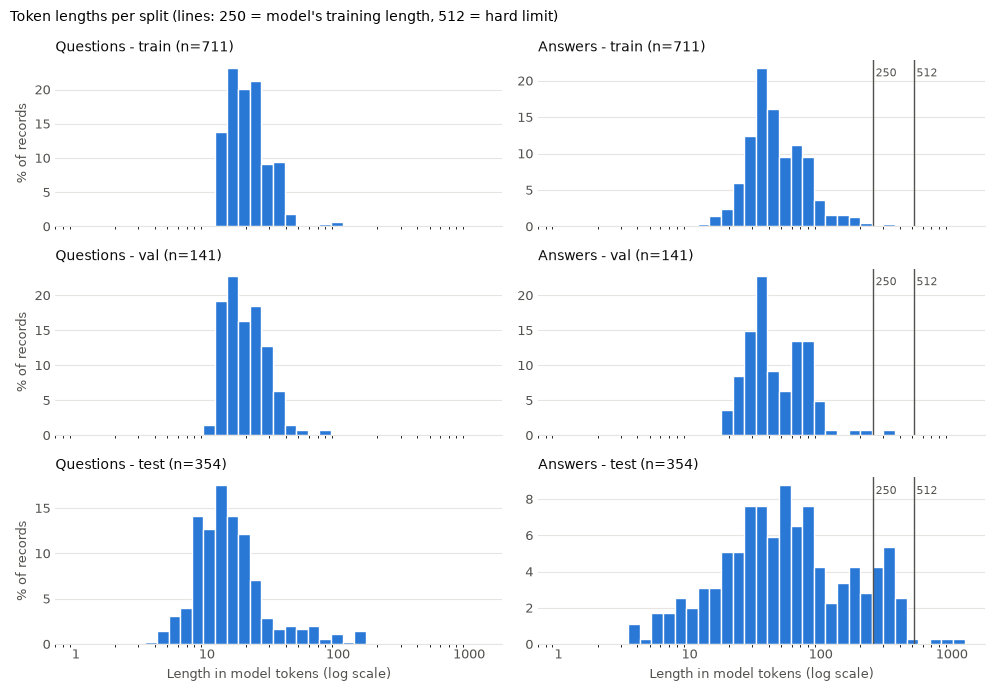

In [17]:
SERIES, GRID, INK, INK2 = "#2a78d6", "#e6e5e1", "#0b0b0b", "#52514e"
bins = np.logspace(0, np.log10(kept[["q_tokens", "a_tokens"]].values.max() * 1.1), 36)
fig, axes = plt.subplots(3, 2, figsize=(10, 7), sharex=True)
for row, split in enumerate(["train", "val", "test"]):
    part = kept[kept.split == split]
    for col, (column, label) in enumerate([("q_tokens", "Questions"), ("a_tokens", "Answers")]):
        ax = axes[row, col]
        ax.hist(part[column], bins=bins, weights=np.full(len(part), 100 / len(part)), color=SERIES, edgecolor="white", linewidth=1)
        ax.set_xscale("log"); ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
        ax.grid(axis="y", color=GRID, linewidth=0.8); ax.set_axisbelow(True)
        for side in ["top", "right", "left"]: ax.spines[side].set_visible(False)
        ax.spines["bottom"].set_color(GRID); ax.tick_params(colors=INK2, labelsize=9, length=0)
        ax.set_title(f"{label} - {split} (n={len(part)})", loc="left", fontsize=10, color=INK)
        if col == 0: ax.set_ylabel("% of records", fontsize=9, color=INK2)
        if col == 1:
            for limit in (250, 512):
                ax.axvline(limit, color=INK2, linewidth=1); ax.text(limit * 1.05, ax.get_ylim()[1] * 0.9, str(limit), fontsize=8, color=INK2)
for ax in axes[-1]: ax.set_xlabel("Length in model tokens (log scale)", fontsize=9, color=INK2)
fig.suptitle("Token lengths per split (lines: 250 = model's training length, 512 = hard limit)", fontsize=10, x=0.01, ha="left")
fig.tight_layout(); fig.savefig(FIGURES_DIR / "token_lengths.png", dpi=200); plt.show()

Questions are well within these limits, with a median of 14 to 20 tokens depending on the set. Most answers also fit, but the test set stands out: its answers have a median of 51.5 tokens, 47 of them are longer than 250 tokens, and 3 are longer than 512. Across the whole dataset, only 5 answers exceed the 512-token limit. We decided not to shorten any answers, because the complete answer should be shown to the user. Only the model's view is limited, since the part of those 5 answers beyond 512 tokens is ignored when they are turned into vectors. The long expert answers in the test set are longer than the texts the model was trained on, so we keep them in mind as a possible source of errors.

## Summary

The preparation started from 1,236 SAQ records and removed 30 of them as duplicates, non-medical records, answers rated as wrong, malformed questions or conflicting answers. The remaining 1,206 records are divided into 711 training, 141 validation and 354 test records. The difference between the crowdsourced training data and the expert test data is the property to keep in mind when reading the results of the next notebooks, the first of which uses these files to define the evaluation method and to measure the TF-IDF baseline and the pretrained model.